# Profiling speed dating users

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# lets check the list of files in our Colab env
!ls

sample_data


## Speed dating data


The speed dating dataset is a dataset collected from a series of speed dating events organized by Columbia Business School professors in collaboration with several universities.

The dataset was later cleaned and analyzed by a team of researchers at Stanford University. The dataset contains information about participants' **demographics**, **preferences**, and **outcomes from the speed dating events**.

The dataset consists of **8378** observations and **195** variables. Each observation corresponds to a **pair of individuals who participated in a speed dating event**, and the variables include **demographic information** (such as *age*, *gender*, *ethnicity*, and *education level*), **self-reported preferences** (such as preferences for a partner's *age*, *ethnicity*, and *income*), and **outcomes** (such as whether the participant **received a match** and whether they **went on a follow-up dat**e with their match).

Some of the variables in the dataset include:
* gender
* age
* race
* education level
* occupation
* income
* self-reported ratings for attractiveness, sincerity, intelligence, and other attributes
* preferences for a partner's age, ethnicity, and income
* whether the participant received a match
* whether the participant went on a follow-up date with their match

The speed dating dataset has been widely used in research on mate selection and social psychology. It has also been used to develop machine learning models to predict match outcomes based on participants' demographic information and self-reported preferences. The dataset is publicly available and can be downloaded from the Stanford University website.

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('https://drive.google.com/uc?id=1wmtMusQYWSMK7tVspqUUdrDBCM80BRCT', encoding='ISO-8859-1')

In [ ]:
data.shape

(8378, 195)

In [ ]:
data.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


## Data explaination

Data is provided on ***date/meeting***  level where  
  - **iid** = id of first person on date
  - **pid** = id of second person on date  

There are 21 dating events: waves (col: wave).

Look into [Speed Dating Data Key.doc](https://docs.google.com/document/d/1B_SXKDrSaw8e20S-2JzlfYP393x9x9AX/edit?usp=sharing&ouid=106769057108648594213&rtpof=true&sd=true) for more details one features/waves

### Data exploration

In [ ]:
# how females scored males attractivenes (attr feature) during first wave?
data.query('wave == 1').query('gender == 0').loc[:,['iid','pid', 'attr', 'gender']]

,iid,pid,attr,gender
0,1,11.0,6.0,0
1,1,12.0,7.0,0
2,1,13.0,5.0,0
3,1,14.0,7.0,0
4,1,15.0,5.0,0
...,...,...,...,...
95,10,16.0,5.0,0
96,10,17.0,5.0,0
97,10,18.0,5.0,0
98,10,19.0,9.0,0


In [ ]:
# lets pivot data as we would expect matrix 10x10 in 1st wave (pivot pid column)
data.query('wave == 1').query('gender == 0').loc[:,['iid','pid', 'attr', 'gender']].pivot(index = ['gender','iid'], columns='pid',values= 'attr')

pid         11.0  12.0  13.0  14.0  15.0  16.0  17.0  18.0  19.0  20.0
gender iid                                                            
0      1     6.0   7.0   5.0   7.0   5.0   4.0   7.0   4.0   7.0   5.0
       2     5.0   8.0   5.0   7.0   6.0   8.0   7.0   5.0   7.0   6.0
       3     7.0   9.0   7.0   9.0   9.0   8.0   8.0   7.0   9.0   8.0
       4     4.0   8.0   4.0   8.0   6.0   5.0   7.0   5.0   9.0   8.0
       5     5.0   8.0   4.0   8.0   6.0   5.0   6.0   5.0   7.0   9.0
       6     6.0   6.0   4.0   8.0   5.0   3.0   8.0   4.0   7.0   8.0
       7     4.0   6.0   3.0   7.0   4.0   4.0   7.0   5.0   6.0   8.0
       8     5.0   8.0   5.0   8.0   6.0   6.0   6.0   5.0   8.0   7.0
       9     8.0  10.0   5.0  10.0   5.0   8.0   6.0   6.0   8.0   7.0
       10    6.0   1.0   6.0  10.0   5.0   5.0   5.0   5.0   9.0   9.0

In [ ]:
# now lets check how females scored males
data.query('wave == 1').query('gender == 1').loc[:,['iid','pid', 'attr', 'gender']].pivot(index = ['gender','iid'], columns='pid',values= 'attr')

pid         1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0
gender iid                                                            
1      11    6.0   8.0   7.0   6.0   6.0   7.0   7.0   8.0   6.0   7.0
       12    7.0   7.0   6.0   6.0   6.0   6.0   7.0   8.0   8.0   1.0
       13   10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
       14    7.0   9.0   7.0   7.0   6.0   6.0   8.0   8.0   7.0   7.0
       15    8.0  10.0   6.0   8.0   5.0   9.0   8.0   9.0   7.0   6.0
       16    7.0   7.0   7.0   6.0   5.0   6.0   8.0   8.0   6.0   NaN
       17    3.0   5.0   6.0   7.0   2.0   5.0   7.0   6.0   8.0   7.0
       18    6.0   7.0   4.0   6.0   5.0   6.0   8.0   9.0   7.0   6.0
       19    7.0   8.0   7.0   7.0   5.0   6.0   9.0   8.0   6.0   7.0
       20    6.0   6.0   5.0   7.0   3.0   7.0   7.0   8.0   5.0   6.0

### How to interpret this??

In males matrix (second), i.e. person with iid 13 scored all females at 10.  
But when we look in females matrix he was scored rather poorly., 3,5,7 (first matrix, col
13)

The opposite situation is with guy with id = 14.  
He was scored rather high (two 10s) comparing to his scores of ladies (one 9 for female with iid = 2).

## EDA

It is worth to generate basic report of whole data. We will use sweetviz package.

In [ ]:
!pip install sweetviz -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 78.7 MB/s eta 0:00:00


### Basic report

In [ ]:
# # # more info on https://pypi.org/project/sweetviz/
# import sweetviz as sv

# my_report = sv.analyze(data,
#                       pairwise_analysis="off")

# my_report.show_notebook()

In [ ]:
# my_report.show_html(filepath='basic_report.html',  layout='vertical')

### Report per gender

In [ ]:
# data1 = data.copy()

# data1['gender'] = data1['gender'].map({0:'Female', 1:'Male'})

# my_report_gender = sv.compare_intra(data1,
#                                     data1["gender"] == "Male",
#                                     ["Male", "Female"],
#                                     pairwise_analysis="off")
# my_report_gender.show_notebook()

In [ ]:
# save
# my_report_gender.show_html(filepath='gender_report.html', layout='vertical')

## Preparing our dataset for clustering

We will take 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1' which describes the **expectations of participants** what people expect from partner during dating event

In [ ]:
data.shape

(8378, 195)

## Getting subset of columns (data_subset)

In [ ]:
# Make data copy
data_subset = data.loc[:, ['wave','iid','pid', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']].copy()
data_subset

,wave,iid,pid,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1
0,1,1,11.0,15.0,20.0,20.0,15.0,15.0,15.0
1,1,1,12.0,15.0,20.0,20.0,15.0,15.0,15.0
2,1,1,13.0,15.0,20.0,20.0,15.0,15.0,15.0
3,1,1,14.0,15.0,20.0,20.0,15.0,15.0,15.0
4,1,1,15.0,15.0,20.0,20.0,15.0,15.0,15.0
...,...,...,...,...,...,...,...,...,...
8373,21,552,526.0,70.0,0.0,15.0,15.0,0.0,0.0
8374,21,552,527.0,70.0,0.0,15.0,15.0,0.0,0.0
8375,21,552,528.0,70.0,0.0,15.0,15.0,0.0,0.0
8376,21,552,529.0,70.0,0.0,15.0,15.0,0.0,0.0


In [ ]:
# Data de-duplication (to keep only one row per participant)
data_subset.drop_duplicates(subset = ['iid'], inplace=True)
data_subset.drop(columns = ['pid'], inplace=True)

KeyError: "['pid'] not found in axis"

In [ ]:
data_subset.loc[:, ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']].apply(sum, axis =1 ).value_counts()

,count
100.00,466
100.01,15
99.99,14
100.01,10
100.02,6
100.00,6
99.99,5
90.00,4
100.00,3
100.02,3


In [ ]:
# data_subset[data_subset.loc[:, ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']].apply(sum, axis =1 ) > 100]

In [ ]:
# Fill missing expectations to 0
data_subset = data_subset.fillna(0)

In [ ]:
data_subset.shape

(551, 8)

## Building K-means clustering algorithm

**K-means** is a clustering algorithm used in **unsupervised** machine learning. It is used to group a set of data points into **K*** number of clusters.

The algorithm works by iteratively assigning each data point to one of K clusters based on the distance between the data point and the center of each cluster, and then recalculating the center of each cluster based on the **mean of the data points in the cluster**.

This process is repeated until the cluster assignments no longer change or a maximum number of iterations is reached.

The value of K is usually chosen by the user based on domain knowledge or using techniques such as the **elbow method** or **silhouette analysis**.

K-means is a widely used clustering algorithm due to its simplicity and efficiency.

In [ ]:
# perform k-means clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

?StandardScaler
?KMeans

In [ ]:
# Before you run K-Means - think about each variable range -
# if, for example, you run K-Means on Income and Age, the algorithm will use predominantly Income to find the clusters,
# as Income is way more varied

# scale the data
scaler = StandardScaler()
data_subset_scaled = scaler.fit_transform(data_subset.loc[:, ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']])
data_subset_scaled

array([[-0.56357468,  0.3952783 ,  0.01192459, -0.33891522,  0.69118926,
         0.51244674],
       [ 1.72202836, -1.6290831 ,  0.70706328,  0.43205261, -1.68129421,
        -1.00249652],
       [ 0.96016068, -0.95429597,  2.09734065, -1.10988305, -0.09963856,
        -1.75996815],
       ...,
       [ 0.57922684, -1.89899795,  1.40220197,  1.97398827, -1.20679752,
        -1.15399085],
       [ 1.34109452,  0.3952783 ,  0.01192459,  0.43205261, -1.68129421,
        -1.75996815],
       [ 3.62669756, -2.30387023, -0.68321409, -0.33891522, -1.68129421,
        -1.75996815]])

In [ ]:
# perform k-means clustering
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
labels = kmeans.fit_predict(data_subset_scaled)

In [ ]:
#Vector with cluster assignments - each observation belongs to one cluster
labels

array([0, 3, 3, 1, 3, 1, 0, 0, 3, 3, 3, 3, 0, 3, 0, 2, 1, 0, 2, 2, 0, 1,
       1, 0, 0, 0, 0, 2, 0, 0, 3, 2, 1, 3, 1, 1, 0, 2, 0, 3, 3, 1, 1, 0,
       1, 1, 3, 3, 1, 3, 1, 3, 2, 3, 1, 0, 0, 2, 2, 0, 0, 3, 3, 1, 0, 0,
       3, 1, 2, 0, 2, 1, 3, 3, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 3, 0, 0, 1, 0, 1, 3, 3, 1, 1, 2, 3, 2, 0, 3, 1, 1, 1, 1, 1,
       1, 0, 3, 1, 3, 0, 0, 2, 3, 3, 3, 2, 2, 0, 1, 1, 3, 3, 2, 0, 0, 0,
       0, 0, 2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 2, 1, 3,
       1, 0, 3, 1, 0, 1, 1, 0, 0, 1, 3, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       3, 1, 1, 0, 0, 1, 3, 1, 3, 0, 1, 2, 3, 1, 1, 1, 3, 2, 3, 3, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 2,

In [ ]:
data_subset['cluster'] = labels
data_subset

,wave,iid,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,cluster
0,1,1,15.0,20.0,20.0,15.0,15.0,15.0,0
10,1,2,45.0,5.0,25.0,20.0,0.0,5.0,3
20,1,3,35.0,10.0,35.0,10.0,10.0,0.0,3
30,1,4,20.0,20.0,20.0,20.0,10.0,10.0,1
40,1,5,20.0,5.0,25.0,25.0,10.0,15.0,3
...,...,...,...,...,...,...,...,...,...
8268,21,548,40.0,10.0,20.0,10.0,0.0,20.0,2
8290,21,549,20.0,20.0,20.0,20.0,0.0,20.0,1
8312,21,550,30.0,3.0,30.0,30.0,3.0,4.0,3
8334,21,551,40.0,20.0,20.0,20.0,0.0,0.0,3


### Prediction

In [ ]:
import numpy as np

#  Now all you need to do to find new coordinates for a given observation (in our case a participant)
#    is to multiply the vector denoting your participants by a vector/matrix of components

# Check what's the score for someone mainly looking for people:
#   Attractive - 'attr1_1'
vec = [70, 0, 0, 10, 10, 10] # <change here>

vec_scaled = scaler.transform(np.array(vec).reshape(1, len(vec)))

In [ ]:
print(f'Selected cluster for vector {vec} is {kmeans.predict(vec_scaled)[0]}')

Selected cluster for vector [70, 0, 0, 10, 10, 10] is 2


### -> Task: Make prediction

Make prediction for following participant's expectations:
* Sincere  - 'sinc1_1' - 0  
  vec = [0, 70, 0, 10, 10, 10]
* Intelligent - 'intel1_1' - 0  
  vec = [0, 0, 70, 10, 10, 10]
* Fun - 'fun1_1' - 2  
  vec = [0, 0, 0, 70, 10, 10]
* Ambitious - 'amb1_1'  
  vec = [0, 10, 0, 10, 70, 10]
* Shared Interest 'shar1_1' - 0  
  vec = [0, 10, 0, 10, 10, 70]

In [ ]:
data_subset_field = pd.merge(data_subset,
                             data.loc[:, ['wave', 'iid', 'field_cd','gender']].drop_duplicates(),
                             left_on = ('wave', 'iid'),
                             right_on =  ('wave','iid'),
                             how = 'left')
# data_subset_field['field_cd'] = data_subset_field['field_cd'].fillna('18').astype(int).astype(str)
data_subset_field

,wave,iid,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,cluster,field_cd,gender
0,1,1,15.0,20.0,20.0,15.0,15.0,15.0,0,1.0,0
1,1,2,45.0,5.0,25.0,20.0,0.0,5.0,3,1.0,0
2,1,3,35.0,10.0,35.0,10.0,10.0,0.0,3,2.0,0
3,1,4,20.0,20.0,20.0,20.0,10.0,10.0,1,1.0,0
4,1,5,20.0,5.0,25.0,25.0,10.0,15.0,3,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...
546,21,548,40.0,10.0,20.0,10.0,0.0,20.0,2,8.0,1
547,21,549,20.0,20.0,20.0,20.0,0.0,20.0,1,8.0,1
548,21,550,30.0,3.0,30.0,30.0,3.0,4.0,3,8.0,1
549,21,551,40.0,20.0,20.0,20.0,0.0,0.0,3,8.0,1


In [ ]:
field_cd_mapper = {1: 'Law',
                   2: 'Math',
                   3: 'Social Science, Psychologist',
                   4: 'Medical Science, Pharmaceuticals, and Bio Tech',
                   5: 'Engineering',
                   6: 'English/Creative Writing/ Journalism',
                   7: 'History/Religion/Philosophy',
                   8: 'Business/Econ/Finance',
                   9: 'Education, Academia',
                   10:'Biological Sciences/Chemistry/Physics',
                   11:'Social Work',
                   12:'Undergrad/undecided',
                   13:'Political Science/International Affairs',
                   14:'Film',
                   15:'Fine Arts/Arts Administration',
                   16:'Languages',
                   17:'Architecture',
                   18:'Other'}

gender_mapper = {0:'Female', 1:'Male'}

data_subset_field['field'] = data_subset_field['field_cd'].fillna(18).map(field_cd_mapper)
data_subset_field['gender_str'] = data_subset_field['gender'].fillna(18).map(gender_mapper)

data_subset_field

,wave,iid,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,cluster,field_cd,gender,field,gender_str
0,1,1,15.0,20.0,20.0,15.0,15.0,15.0,0,1.0,0,Law,Female
1,1,2,45.0,5.0,25.0,20.0,0.0,5.0,3,1.0,0,Law,Female
2,1,3,35.0,10.0,35.0,10.0,10.0,0.0,3,2.0,0,Math,Female
3,1,4,20.0,20.0,20.0,20.0,10.0,10.0,1,1.0,0,Law,Female
4,1,5,20.0,5.0,25.0,25.0,10.0,15.0,3,1.0,0,Law,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,21,548,40.0,10.0,20.0,10.0,0.0,20.0,2,8.0,1,Business/Econ/Finance,Male
547,21,549,20.0,20.0,20.0,20.0,0.0,20.0,1,8.0,1,Business/Econ/Finance,Male
548,21,550,30.0,3.0,30.0,30.0,3.0,4.0,3,8.0,1,Business/Econ/Finance,Male
549,21,551,40.0,20.0,20.0,20.0,0.0,0.0,3,8.0,1,Business/Econ/Finance,Male


In [ ]:
data_subset_field.value_counts('gender_str')

,count
gender_str,
Male,277
Female,274


In [ ]:
import plotly.express as px
fig = px.histogram(data_subset_field, x="field", color="gender_str", facet_col='cluster', barmode="overlay" )
fig.show()

## Clusters viz - manual

In [ ]:
df_viz = pd.DataFrame(data_subset_scaled,
                      columns = data_subset.loc[:, ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']].columns)

df_viz['labels'] = labels
df_viz_ = df_viz.groupby('labels').mean().reset_index().melt(id_vars = ['labels'])


fig = px.line_polar(df_viz_,
                    r = "value",
                    theta = "variable",
                    line_close = True,
                    color = "labels",
                    color_discrete_sequence = px.colors.sequential.Plasma_r)


fig.update_layout(polar = dict(
    radialaxis = dict(
      visible = True,
      range = [-2, 3]
    )),
  showlegend = True
)

fig.show()

In [ ]:
df_viz =  data_subset.loc[:, ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']].fillna(0)
df_viz['labels'] = labels
df_viz_ = df_viz.groupby('labels').mean().reset_index().melt(id_vars=['labels'])

fig = px.line_polar(df_viz_, r="value",
                    theta="variable",
                    line_close=True,
                    color="labels",
                    color_discrete_sequence=px.colors.sequential.Plasma_r)


fig.update_layout(polar=dict(
    radialaxis=dict(
        visible=True,
      range=[0, 55]
    )),
  showlegend=True
)

fig.show()

## Visualize clusters with PCA

**PCA** stands for **Principal Component Analysis**.
It is a technique used in **unsupervised** machine learning and data science to **reduce the dimensionality of large datasets**.

**PCA** works by finding the **principal component**s, which are the directions in the data that explain the most variance. These components are orthogonal to each other and are sorted in descending order of the amount of variance that they explain. The first principal component explains the most variance, the second principal component explains the second most variance, and so on.

PCA can be used to reduce the dimensionality of a dataset by **projecting it onto a lower-dimensional space** defined by the principal components. This can help to simplify the data and remove noise or irrelevant features.

PCA is widely used in a variety of applications, such as image and speech recognition, data compression, and visualization.

In Python, you can use the PCA class from the `sklearn.decomposition` module to perform PCA on a dataset.

### 2D

In [ ]:
from sklearn.decomposition import PCA

# perform PCA
pca = PCA(n_components=2) #We can generate more than 2 components (up to the #variables in our dataset)
data_subset_pca = pca.fit_transform(data_subset_scaled)
data_subset_pca #Transformed dataset

array([[-1.05395796, -0.34714144],
       [ 2.78310354,  0.86099239],
       [ 1.39176233,  0.5088356 ],
       ...,
       [ 1.84692905,  2.7272506 ],
       [ 2.26997468,  0.2882477 ],
       [ 4.88274548, -0.11502331]])

In [ ]:
#Getting it back into Pandas data frame
data_subset_tf = pd.concat([pd.DataFrame(data_subset_pca, columns=['PC1', 'PC2']),
                           pd.DataFrame(labels, columns=['labels'])], axis=1)
data_subset_tf

,PC1,PC2,labels
0,-1.053958,-0.347141,0
1,2.783104,0.860992,3
2,1.391762,0.508836,3
3,-0.113240,0.317114,1
4,0.148998,1.568546,3
...,...,...,...
546,1.421401,-1.457320,2
547,-0.068871,-0.390778,1
548,1.846929,2.727251,3
549,2.269975,0.288248,3


<Axes: xlabel='PC1', ylabel='PC2'>

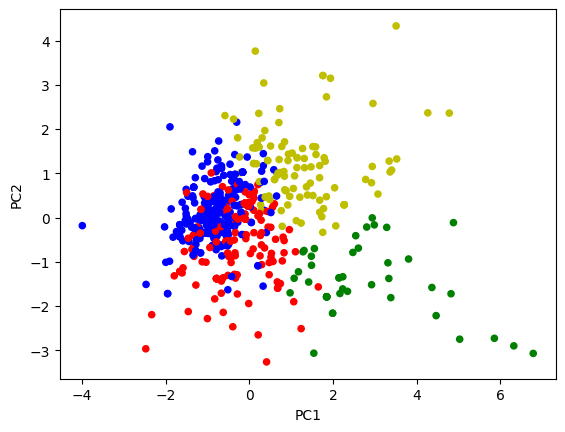

In [ ]:
#More readable scatterplot, where colors indicate clusters
data_subset_tf.plot.scatter(x='PC1', y='PC2', c=data_subset_tf.labels.replace([0, 1, 2, 3], ['b', 'r', 'g', 'y']))

In [ ]:
# To better understand what happened, we can check eigenvectors/coefficients/loadings/components - that is, vectors used for obtaining our new coordinates
# 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1'
print(pca.components_)

[[ 0.64814379 -0.36655405 -0.19851779 -0.00517552 -0.45521444 -0.4459725 ]
 [-0.16800079 -0.31034093  0.34849635  0.79729766  0.15198277 -0.30859718]]


In [ ]:
#you can check that sum of squred loading scores sums up to 1 (as eigenvector is normalized)
print("PC1", sum([x**2 for x in pca.components_[0]]))
print("PC2", sum([x**2 for x in pca.components_[1]]))

PC1 1.0
PC2 1.0000000000000009


In [ ]:
# also PC1 value comes mainly (45%) from 1st column (in our case attr1_1)
[(x**2)/sum([x**2 for x in pca.components_[0]]) for x in pca.components_[0]]

[0.42009037081381967,
 0.13436187064450794,
 0.03940931383703476,
 2.6786038396418122e-05,
 0.20722018911092083,
 0.19889146955532044]

In [ ]:
# in PC2 case from 4th (70% - fun1_1)
[(x**2)/sum([x**2 for x in pca.components_[1]]) for x in pca.components_[1]]

[0.028224265760234193,
 0.09631149039313272,
 0.12144970384225734,
 0.6356835613349063,
 0.023098761082537913,
 0.09523221758693137]

#### Calculate PCAs

In [ ]:
import numpy as np

#  Now all you need to do to find new coordinates for a given observation (in our case a participant)
#    is to multiply the vector denoting your participants by a vector/matrix of components

# Check what's the score for someone mainly looking for people:
#   Attractive - 'attr1_1'
vec = [70, 0, 10, 10, 0, 10]

vec_scaled = scaler.transform(np.array(vec).reshape(1, len(vec)))
np.matmul(pca.components_, vec_scaled.flatten())

array([ 4.34911001, -1.43947466])

### 3D

In [ ]:
# Perform PCA
pca = PCA(n_components=3) #We can generate more than 2 components (up to the #variables in our dataset)
data_subset_pca = pca.fit_transform(data_subset_scaled)
data_subset_pca #Transformed dataset

array([[-1.05395796, -0.34714144, -0.09382982],
       [ 2.78310354,  0.86099239,  0.92799756],
       [ 1.39176233,  0.5088356 ,  2.56932958],
       ...,
       [ 1.84692905,  2.7272506 ,  0.84914978],
       [ 2.26997468,  0.2882477 ,  0.58073151],
       [ 4.88274548, -0.11502331,  0.11766338]])

In [ ]:
# Getting it back into Pandas data frame
data_subset_tf = pd.concat([pd.DataFrame(data_subset_pca, columns=['PC1', 'PC2','PC3']),
                           pd.DataFrame(labels, columns=['labels'])], axis=1)
data_subset_tf

,PC1,PC2,PC3,labels
0,-1.053958,-0.347141,-0.093830,0
1,2.783104,0.860992,0.927998,3
2,1.391762,0.508836,2.569330,3
3,-0.113240,0.317114,-0.067232,1
4,0.148998,1.568546,-0.017350,3
...,...,...,...,...
546,1.421401,-1.457320,0.512553,2
547,-0.068871,-0.390778,-0.006077,1
548,1.846929,2.727251,0.849150,3
549,2.269975,0.288248,0.580732,3


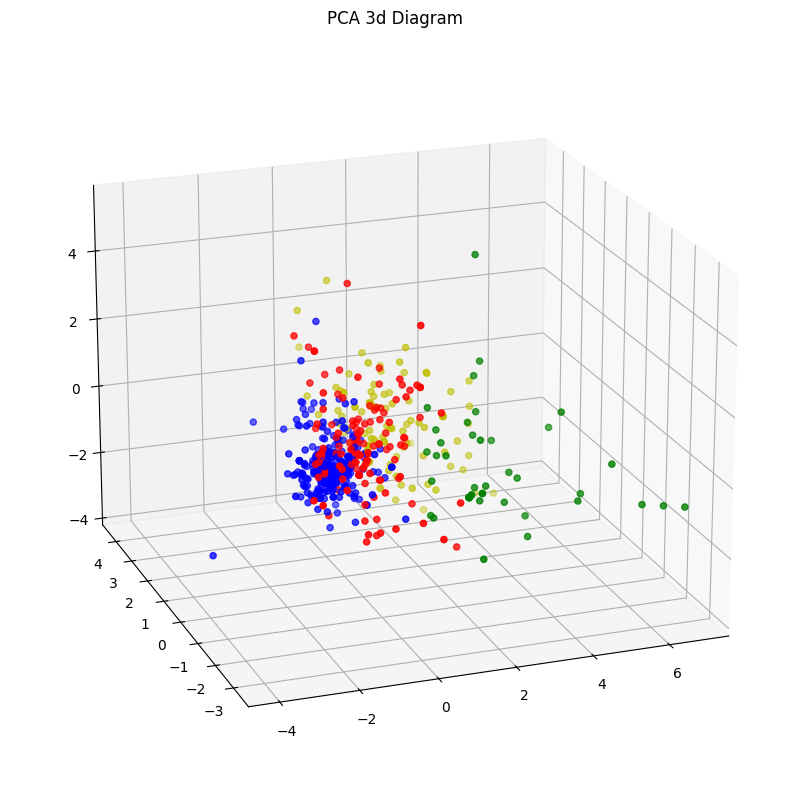

In [ ]:
import matplotlib.pyplot as plt
# Getting it back into Pandas data frame
data_subset_tf = pd.concat([pd.DataFrame(data_subset_pca, columns=['PC1', 'PC2','PC3']),
                           pd.DataFrame(labels, columns=['labels'])], axis=1)
data_subset_tf

# Creating figure
fig = plt.figure(figsize = (15, 10))
ax = plt.axes(projection ="3d")

# Creating plot
ax.scatter3D(xs = data_subset_tf.PC1,
             ys = data_subset_tf.PC2,
             zs = data_subset_tf.PC3,
             color = list(data_subset_tf.labels.replace([0, 1, 2, 3], ['b', 'r', 'g', 'y'])))
plt.title("PCA 3d Diagram")
ax.view_init(20, 250)
# show plot
plt.show()

### Scree plot, how many PCs?

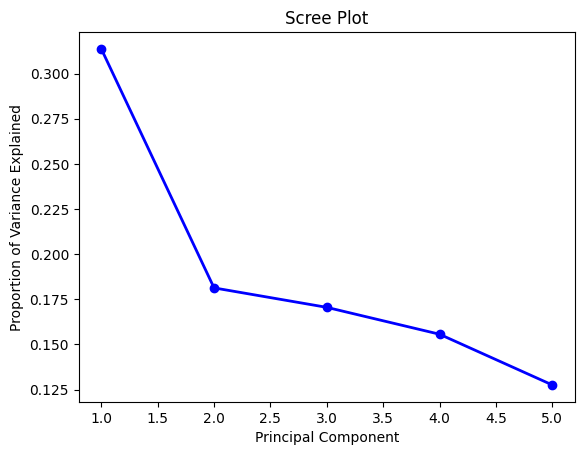

In [ ]:
# instantiate a PCA object and set the number of components to 5
pca = PCA(n_components=5)

# fit the dataset using PCA
pca.fit(data_subset_scaled)

# calculate the proportion of variance explained by each component
explained_variance_ratio = pca.explained_variance_ratio_

# create a scree plot
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 'bo-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.show()

# How to define clusters in clustering algorithms?

There are multiple methods, out of which the most popular are:
- Elbow method
- Silhouette (try at home)

The **Elbow method** is a technique used to determine the optimal number of clusters in a dataset. It works by plotting the **within-cluster sum of squares (WCSS)** for different values of **k** (the number of clusters) and looking for an "elbow" or bend in the plot. The idea is that as the number of clusters increases, the WCSS should decrease, but **at some point, the benefit of adding more clusters will be marginal**, and the elbow point indicates the optimal number of clusters.

The **Silhouette metho**d is another technique used to evaluate the quality of clustering results. It works by calculating a **silhouette scor**e for each data point, which measures how similar the data point is to its own cluster compared to other clusters. The silhouette score ranges from -1 to 1, with values closer to 1 indicating that the data point is well-clustered, and values closer to -1 indicating that the data point may be assigned to the wrong cluster.

Here's an example of how to use the Silhouette method in Python with k-means clustering:

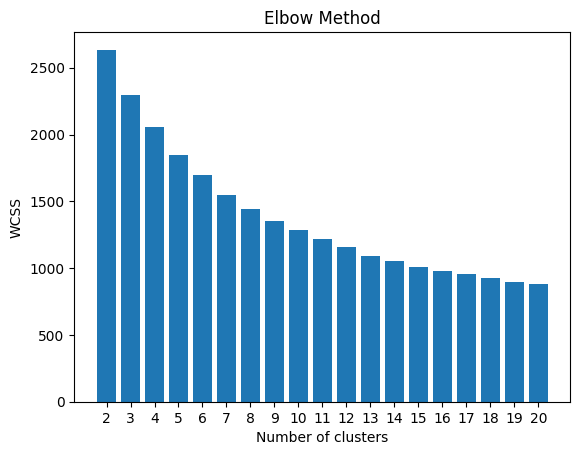

In [ ]:
# calculate WCSS for different k values
wcss = []
for i in range(2,21):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(data_subset_scaled)
    wcss.append(kmeans.inertia_)

# plot the elbow curve
plt.bar([str(i) for i in range(2,21)], wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# load dataset
# df = pd.read_csv('dataset.csv')

# calculate Silhouette score for different k values
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    labels = kmeans.fit_predict(data_subset_scaled)
    silhouette_scores.append((i, silhouette_score(data_subset_scaled, labels)))


In [ ]:
silhouette_scores

[(2, 0.3565183674403474),
 (3, 0.20589924471750137),
 (4, 0.20341559536062404),
 (5, 0.2234697344916384),
 (6, 0.24771608855421415),
 (7, 0.2201129443811295),
 (8, 0.19907960333214902),
 (9, 0.1859546505354711),
 (10, 0.20152416287569114)]

In [ ]:
# find the best value of k based on the Silhouette score
best_k = silhouette_scores.index(max(silhouette_scores))

print(f"The optimal number of clusters is {best_k} with a Silhouette score of {max(silhouette_scores)}")
silhouette_scores

The optimal number of clusters is 8 with a Silhouette score of (10, 0.20152416287569114)


[(2, 0.3565183674403474),
 (3, 0.20589924471750137),
 (4, 0.20341559536062404),
 (5, 0.2234697344916384),
 (6, 0.24771608855421415),
 (7, 0.2201129443811295),
 (8, 0.19907960333214902),
 (9, 0.1859546505354711),
 (10, 0.20152416287569114)]